In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt

import numpy as np
import scipy as sp
from scipy import special as scisp
from scipy.integrate import solve_ivp
from scipy.interpolate import InterpolatedUnivariateSpline,CubicSpline
import scipy.integrate
import scipy.optimize
import multiprocessing
from tqdm import trange
from scipy.optimize import curve_fit
import matplotlib.cm as cm
from matplotlib.gridspec import GridSpec
from scipy.interpolate import interp1d
from matplotlib.ticker import LogLocator, NullFormatter
import sys
from pathlib import Path
# add main_directory/ to the import path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))
from source.SecludedDM import Cosmology, VectorPortal, BoltzmannSolver, find_mXstar

plt.style.use('/home/gab/Desktop/PyCharm_env/mine.mplstyle')
plt.rcParams["axes.axisbelow"] = False

In [5]:
alphaXv=1e-3
rv=1.5
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")

def vp_factory_smallD3(mX, mY):
    return VectorPortal(mX=mX, mY=mY, alphaX=alphaXv,
                        Delta1=1e-1, Delta2=1e-1, Delta3=1e-1)

res_smallD3s = find_mXstar(cosmo, vp_factory_smallD3, r=rv, verbose=True,
                           solver_kw=dict(convergence_mode="dlnxi_NR", convergence_threshold=1e-2,
                                          cannibal_switch_full=1e-3),
                           bracket_factor=(.2,2), delta_S=5e-4)
print(res_smallD3s['mXstar'], res_smallD3s['epsX_min'])

find_mXstar  (r=1.50)
  mX_est = 5.78e+01 GeV  bracket = [1.16e+01, 1.16e+02]
------------------------------------------------------------
  lo: mX=1.16e+01 -> mX*YX=2.47e-10
  hi: mX=1.16e+02 -> mX*YX=1.21e-08
  guess: mX = 1.6213e+01
  refine: mX=8.1063e+00 -> mX*YX=1.3315e-10
  refine: mX=1.1464e+01 -> mX*YX=2.4355e-10
  refine: mX=1.6213e+01 -> mX*YX=4.3839e-10
  refine: mX=2.2928e+01 -> mX*YX=7.7766e-10
  refine: mX=3.2425e+01 -> mX*YX=1.3859e-09
  => mX* = 1.6191e+01 GeV  mY* = 1.0794e+01 GeV  Och2 = 0.120000
  => epsX_min = 2.6303e-09  (dS/S < 0.0005)  SRatio_plateau = 2.7952
16.19075558807518 2.6302610206803225e-09


In [ ]:
mXs=np.linspace(res_smallD3s['mXstar']*(1+1e-2),5*res_smallD3s['mXstar'],100)
mYs=mXs/rv
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
        Delta1=1e-2,Delta2=1e-2,Delta3=1e-2,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_3phase(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6,cannibal_switch_full= 7e-2,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18, convergence_mode= "dlnxi_NR",
                                           convergence_threshold=2e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"alphaX={alphaXv:.1e}  r={rv}  mXstar={res_smallD3s['mXstar']:.6e}  "
          f"epsX_min={res_smallD3s['epsX_min']:.6e}  SRatio_plateau={res_smallD3s['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/relic_aX{alphaXv:.0e}_r{rv}_D123_1e-2.dat", data, header=header, fmt='%.8e')

In [ ]:
def vp_factory_infl05(mX, mY):
    return VectorPortal(mX=mX, mY=mY, alphaX=alphaXv, xi_ini=0.5)

res_infl05 = find_mXstar(cosmo, vp_factory_infl05, r=rv, verbose=True,
                          solver_kw=dict(convergence_mode="dlnxi_NR", convergence_threshold=1e-2,
                                         cannibal_switch_full=1e-1),
                          delta_S=5e-4)
print(res_infl05['mXstar'], res_infl05['epsX_min'])

In [ ]:
mXs=np.linspace(res_infl05['mXstar']*(1+1e-2),5*res_infl05['mXstar'],100)
mYs=mXs/rv
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
        xi_ini=.5,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_3phase(return_bg_ICs=True, verbose=False,
                                                 Gamma_switch_QSSA=5e9, Gamma_switch_full=2e6, cannibal_switch_full=1,
                                                 n_points=500, rtol_value=1e-6, atol_value=1e-18, convergence_mode= "dlnxi_NR",
                                           convergence_threshold=2e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-18,-8),root_rtol= 1e-4)
    epsXs_bbn[i]=solver.find_epsilon_BBN_Neff(sol0['bg_ICs'],T_eval=1e-3,log10eps_range=(-15,-9),root_rtol=1e-3)
    del model, solver
data = np.column_stack([mXs, mYs, epsXs, epsXs_bbn])
header = (f"alphaX={alphaXv:.1e}  r={rv}  mXstar={res_infl05['mXstar']:.6e}  "
          f"epsX_min={res_infl05['epsX_min']:.6e}  SRatio_plateau={res_infl05['SRatio_plateau']:.4f}\n"
          f"mX [GeV]    mY [GeV]    epsX_relic    epsX_bbn_Neff")
np.savetxt(f"../output/relic_aX{alphaXv:.0e}_r{rv}_xiinfl05_v2.dat", data, header=header, fmt='%.8e')

In [ ]:
# 1) Initialise the SM background (point gstar_dir to wherever std.tab lives)
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")

# 2) Build the dark-sector model
model = VectorPortal(
    mX=5e1,       
    mY=2e1,       
    gX=2, gY=3,
    alphaX=1e-3,
    include_antiparticlesX=True,
    include_antiparticlesY=False,
)

# 3) Create solver and run
solver = BoltzmannSolver(cosmo, model)
sol0 = solver.solve_boltzmann_chempot_2phase(return_bg_ICs=True, verbose=True,Gamma_switch_threshold=5e6, n_points=500, rtol_value=1e-6,
        atol_value=1e-18,convergence_threshold=5e-3)

In [5]:
def xi_asymptotic(x, mX, xi0, x0):
    """
    Solve d ln xi / dx = (1 - 2*tildeg(T)) / x with xi(x0)=xi0,
    where T = mX / x.

    Vectorized in x. Assumes tildeg(T) behaves like your _interp wrapper:
    scalar -> scalar, array -> array.
    """
    x = np.asarray(x, dtype=float)

    if np.any(x <= 0) or x0 <= 0:
        raise ValueError("x and x0 must be positive.")
    if xi0 <= 0:
        raise ValueError("xi0 must be positive (since we evolve ln xi).")

    # Build integration grid that includes x0 and all requested x values
    x_flat = np.ravel(x)
    x_all = np.concatenate(([float(x0)], x_flat))

    order = np.argsort(x_all)
    xs = x_all[order]

    # Evaluate tildeg on the grid
    Ts = mX / xs
    gtil = cosmo.g_tilde(Ts)

    f = (1.0 - 2.0 * gtil) / xs  # integrand for d(ln xi)/dx
    #f = -1/xs
    # Cumulative trapezoid integral from xs[0] to xs[i]
    cum = np.empty_like(xs)
    cum[0] = 0.0
    dxs = np.diff(xs)
    cum[1:] = np.cumsum(0.5 * (f[1:] + f[:-1]) * dxs)

    # Find where x0 landed in the sorted grid, and anchor there
    # (x0 is exactly included, so this should hit)
    idx0 = np.where(xs == float(x0))[0]
    if idx0.size == 0:
        # very defensive fallback for floating issues
        idx0 = np.argmin(np.abs(xs - float(x0)))
    else:
        idx0 = idx0[0]

    lnxi_grid = np.log(xi0) + (cum - cum[idx0])

    # Interpolate lnxi back to requested x values (fast)
    lnxi_flat = np.interp(x_flat, xs, lnxi_grid)
    xi_out = np.exp(lnxi_flat).reshape(x.shape)

    return xi_out.item() if xi_out.ndim == 0 else xi_out
xi_lim=xi_asymptotic(sol0['x'],5e1,sol0['xi'][-1],sol0['x'][-1])

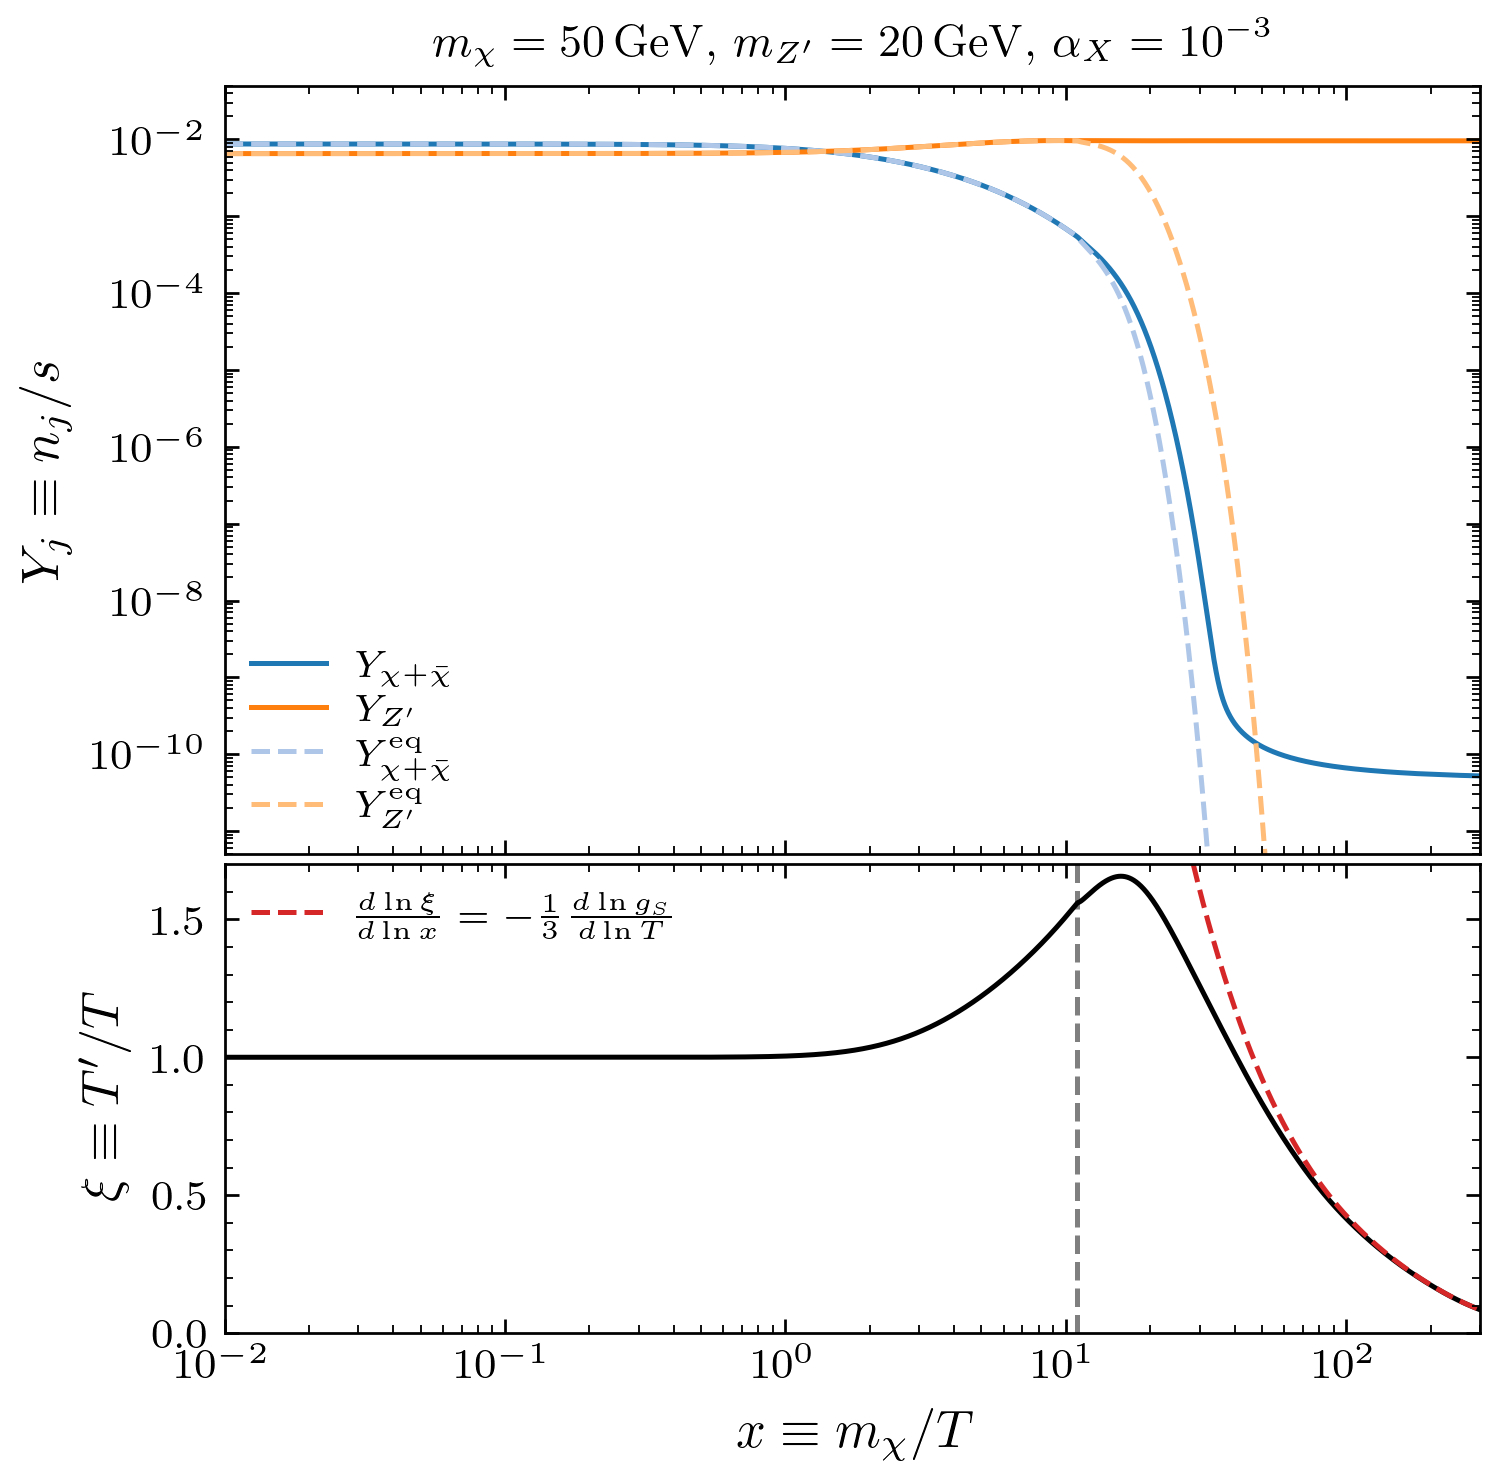

In [12]:

cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(4.5, 4.5))
#fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(21,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:13,:])
ax2 = fig1.add_subplot(gs1[13:,:])
ax1.set_title(r'$m_{\chi}=50\,{\rm GeV},\,m_{Z^\prime}=20\,{\rm GeV},\, \alpha_X=10^{-3}$',fontsize=9)
ax1.plot(sol0['x'],sol0['YX'],lw=1,c=cs[0],label=r'$Y_{\chi+\bar\chi}$')
ax1.plot(sol0['x'],sol0['YY'],lw=1,c=cs[2],label=r'$Y_{Z^\prime}$')
ax1.plot(sol0['x'],sol0['YXeq'],lw=1,c=cs[1],ls='--',label=r'$Y^{\rm eq}_{\chi+\bar\chi}$')
ax1.plot(sol0['x'],sol0['YYeq'],lw=1,c=cs[3],ls='--',label=r'$Y^{\rm eq}_{Z^\prime}$')
ax1.legend()
ax2.plot(sol0['x'],sol0['xi'],lw=1,c='k')
ax2.plot(sol0['x'],xi_lim,lw=1,c='tab:red',ls='--',label=r'$\frac{d\ln \xi}{d\ln x}= -\frac{1}{3}\frac{d\ln{g}_S}{d\ln T}$')
ax2.legend()
ax2.axvline(sol0['x_switch'],lw=1,ls='--',c='tab:gray',zorder=-1)
ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.set_yscale("log")
ax1.set_ylabel(r"$Y_{j}\equiv n_j/s$")
ax2.set_ylabel(r"$\xi\equiv T^\prime/T$")
ax2.set_xlabel(r"$x\equiv m_\chi/T$")
ax1.set_ylim(5e-12,5e-2)
ax1.set_xlim(1e-2,3e2)
ax2.set_xlim(1e-2,3e2)
ax1.set_xticklabels([])
ax2.set_ylim(0.,1.7)
ax1.set_yticks([1e-11,1e-10,1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2])
ax1.set_yticklabels(['',r'$10^{-10}$','',r'$10^{-8}$','',r'$10^{-6}$','',r'$10^{-4}$','',r'$10^{-2}$'])
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.yaxis.set_minor_formatter(NullFormatter())
plt.savefig("../figs/YEvs_mX50_mY20_alphaX1e-3.pdf")
plt.savefig("../figs/YEvs_mX50_mY20_alphaX1e-3.png")
plt.show()
plt.close()

In [ ]:
epsX= solver.find_epsilon_DMRelic(sol0['bg_ICs'])
print(epsX)
# 4) Run background evolution for a particular epsilon
sol_bg = solver.solve_background(epsX=epsX, bg_ICs=sol0['bg_ICs'],
                          stop_on_rhoY=False, verbose=False)

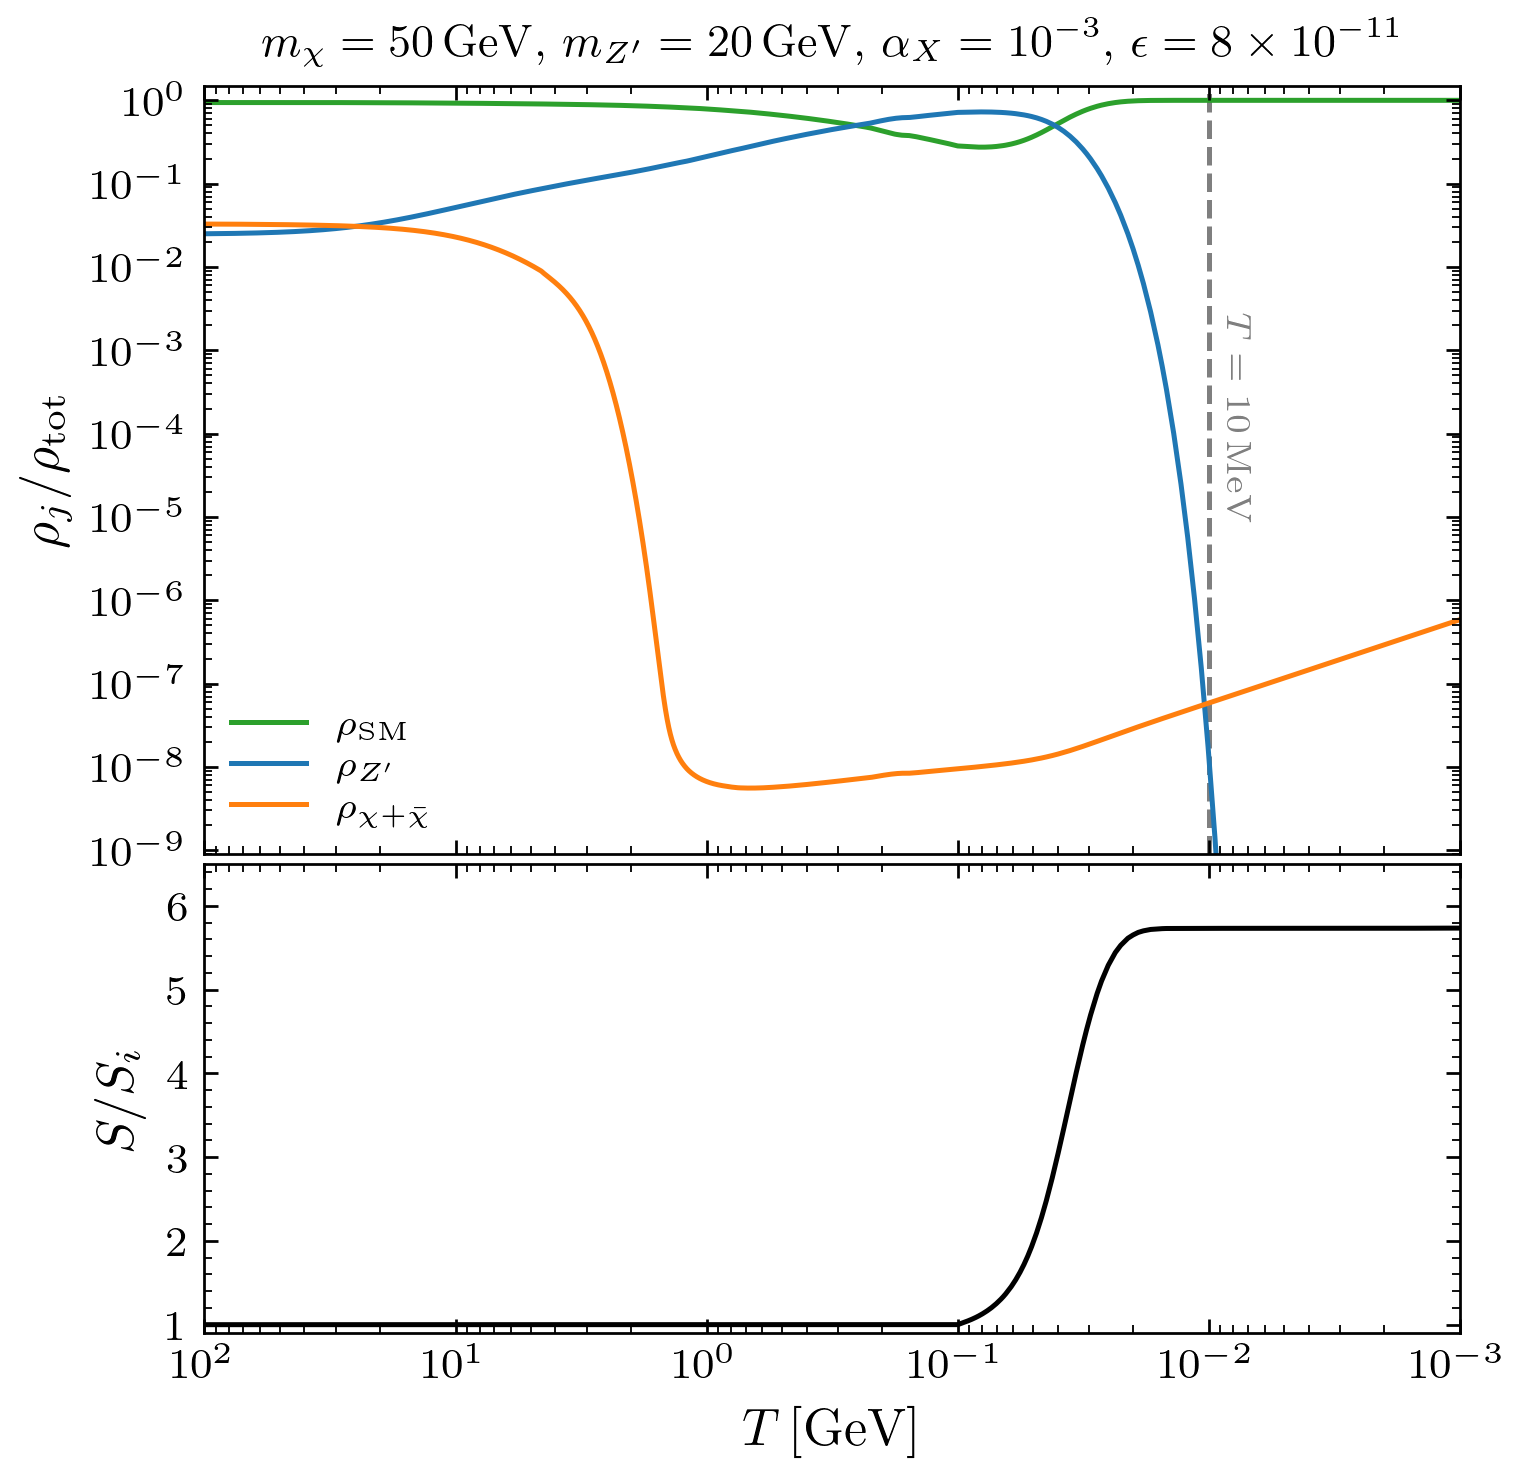

In [18]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
fig1=plt.figure(figsize=(4.5, 4.5))
#fig1=plt.figure(figsize=(7.5, 7.5/1.61803398875*0.5))
gs1 = GridSpec(21,23,figure=fig1)
ax1 = fig1.add_subplot(gs1[:13,:])
ax2 = fig1.add_subplot(gs1[13:,:])
ax1.set_title(r'$m_{\chi}=50\,{\rm GeV},\,m_{Z^\prime}=20\,{\rm GeV},\, \alpha_X=10^{-3},\,\epsilon=8\times 10^{-11}$',fontsize=9)

ax1.plot(sol_bg['T'],sol_bg['rhoR']/sol_bg['rhoTot'],lw=1,c=cs[4],label=r'$\rho_{\rm SM}$')
ax1.plot(sol_bg['T'],sol_bg['rhoY']/sol_bg['rhoTot'],lw=1,c=cs[0],label=r'$\rho_{Z^\prime}$')
ax1.plot(sol_bg['T'],sol_bg['rhoX']/sol_bg['rhoTot'],lw=1,c=cs[2],label=r'$\rho_{\chi+\bar\chi}$')

ax1.set_ylim(.9e-9,1.5)
ax1.set_yscale("log")
ax1.set_xscale("log")
ax2.set_xscale("log")
ax1.axvline(1e-2,ls='--',c='tab:gray',zorder=-1,lw=1)
ax1.text(0.9*1e-2,1e-5,r'$T=10\,{\rm MeV}$',rotation=270, fontdict={'fontsize':7,'family':'serif','color':'tab:gray'})
ax2.set_xlabel(r"$T\,[\rm GeV]$")
ax1.set_ylabel(r"$\rho_j/\rho_{\rm tot}$")
ax1.invert_xaxis()
ax2.invert_xaxis()
ax1.set_xlim(1e2,1e-3)
ax2.set_xlim(1e2,1e-3)
ax1.set_xticklabels([])

ax2.plot(sol_bg['T'],sol_bg['SoverSi'],lw=1,c='k')
ax2.set_ylabel(r'$S/S_i$')
ax2.set_ylim(0.9,6.5)
ax2.set_yticks([1,2,3,4,5,6])
ax1.legend()
ax1.set_yticks([1e-9,1e-8,1e-7,1e-6,1e-5,1e-4,1e-3,1e-2,1e-1,1])
ax1.yaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.yaxis.set_minor_formatter(NullFormatter())
#ax2.set_yticks([1,1e1,1e2,1e3,1e4])
ax2.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax2.xaxis.set_minor_formatter(NullFormatter())
ax1.xaxis.set_minor_locator(LogLocator(base=10.0, subs=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,.9], numticks=2000))
ax1.xaxis.set_minor_formatter(NullFormatter())
plt.savefig("../figs/bgEvs_mX50_mY20_alphaX1e-3_epsX8e-11.pdf")
plt.savefig("../figs/bgEvs_mX50_mY20_alphaX1e-3_epsX8e-11.png")
plt.show()
plt.close()


In [16]:
mXs=np.arange(15,60,5)
mXs=np.arange(15,60,5)
print(mXs)

[15 20 25 30 35 40 45 50 55]


In [ ]:
# --- Cosmological observables ---
s0_cosmo = 2891.0          # entropy density today  (cm^-3)
rhoc     = 1.05375e-5      # critical density       (GeV h^2 cm^-3)
Och2     = 0.12            # Omega_c h^2
mY_relic = Och2 * rhoc / s0_cosmo   # reference relic yield (GeV)

# 1) Initialise the SM background (point gstar_dir to wherever std.tab lives)
cosmo = Cosmology(gstar_choice="standard", gstarpath="./")
alphaXv=5e-4

mXs=np.arange(15,60,5)
mYs=mXs/50*20
epsXs=np.zeros(len(mXs))
epsXs_bbn=np.zeros(len(mXs))
for i in trange(len(mXs)):
    model = VectorPortal(
        mX=mXs[i],       
        mY=mYs[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
    )
    solver = BoltzmannSolver(cosmo, model)
    # 3) Run the Boltzmann solver
    sol0 = solver.solve_boltzmann_chempot_2phase(return_bg_ICs=True, verbose=False,Gamma_switch_threshold=5e6, n_points=500, rtol_value=1e-8, atol_value=1e-18,
                                      convergence_threshold=1e-2)
    epsXs[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-25,0))
    epsXs_bbn[i]= solver.find_epsilon_BBN(sol0['bg_ICs'],T_BBN=1e-2,rhoY_threshold=1e-2)
    del model, solver

In [ ]:
alphaXv=1e-3

mXs_v2=np.arange(40,60,5)
mYs_v2=mXs_v2/50*20
epsXs_v2=np.zeros(len(mXs_v2))
epsXs_bbn_v2=np.zeros(len(mXs_v2))
for i in trange(len(mXs_v2)):
    model = VectorPortal(
        mX=mXs_v2[i],       
        mY=mYs_v2[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_2phase(return_bg_ICs=True, verbose=False,Gamma_switch_threshold=5e6, n_points=500, rtol_value=1e-8, atol_value=1e-18,
                                      convergence_threshold=1e-2)
    epsXs_v2[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-25,0))
    epsXs_bbn_v2[i]= solver.find_epsilon_BBN(sol0['bg_ICs'],T_BBN=1e-2,rhoY_threshold=1e-2)
    del model, solver

In [ ]:
alphaXv=4e-3

mXs_v3=np.arange(30,90,5)
mYs_v3=mXs_v3/1.3
epsXs_v3=np.zeros(len(mXs_v3))
epsXs_bbn_v3=np.zeros(len(mXs_v3))
for i in trange(len(mXs_v3)):
    model = VectorPortal(
        mX=mXs_v3[i],       
        mY=mYs_v3[i],       
        gX=2, gY=3,
        alphaX=alphaXv,
        include_antiparticlesX=True,
        include_antiparticlesY=False,
    )
    solver = BoltzmannSolver(cosmo, model)
    sol0 = solver.solve_boltzmann_chempot_2phase(return_bg_ICs=True, verbose=False,Gamma_switch_threshold=2e6, n_points=500, rtol_value=1e-8, atol_value=1e-18,
                                      convergence_threshold=1e-2)
    print(sol0['YX_relic']*mXs_v3[i]/mY_relic)
    epsXs_v3[i]= solver.find_epsilon_DMRelic(sol0['bg_ICs'],log10eps_range=(-25,0))
    epsXs_bbn_v3[i]= solver.find_epsilon_BBN(sol0['bg_ICs'],T_BBN=1e-2,rhoY_threshold=1e-2)
    print(epsXs_v3[i],epsXs_bbn_v3[i])
    del model, solver

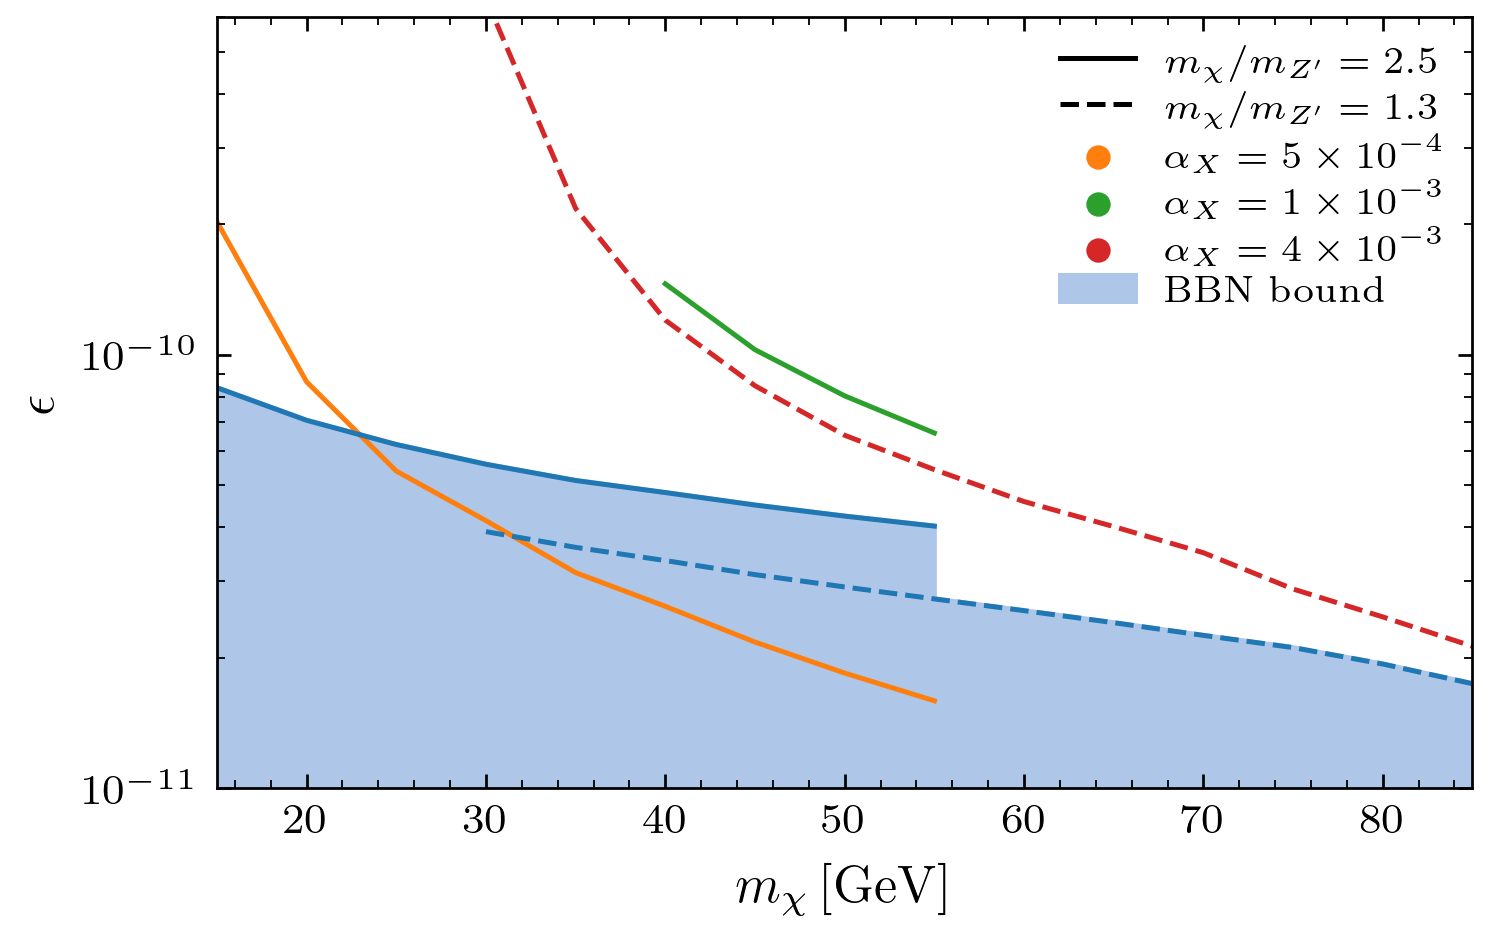

In [67]:
cs=plt.cm.tab20([0,1,2,3,4,5,6,7,8])
plt.plot(mXs,epsXs,lw=1,c=cs[2])
plt.plot(mXs_v2,epsXs_v2,lw=1,c=cs[4],ls='-')
plt.plot(mXs_v3,epsXs_v3,lw=1,c=cs[6],ls='--')
plt.scatter(np.NaN,np.NaN,color=cs[2],marker='o',s=15,label=r'$\alpha_X=5\times 10^{-4}$')
plt.scatter(np.NaN,np.NaN,color=cs[4],marker='o',s=15,label=r'$\alpha_X=1\times 10^{-3}$')
plt.scatter(np.NaN,np.NaN,color=cs[6],marker='o',s=15,label=r'$\alpha_X=4\times 10^{-3}$')
plt.plot(np.NaN,np.NaN,c='k',lw=1,ls='-',label=r'$m_\chi/m_{Z^\prime}=2.5$')
plt.plot(np.NaN,np.NaN,c='k',lw=1,ls='--',label=r'$m_\chi/m_{Z^\prime}=1.3$')
plt.fill_between(mXs,0,epsXs_bbn,lw=1,color=cs[1],label=r'BBN bound',alpha=1)
plt.plot(mXs,epsXs_bbn,lw=1,color=cs[0])
plt.fill_between(mXs_v3,0,epsXs_bbn_v3,lw=1,color=cs[1],alpha=1)
plt.plot(mXs_v3,epsXs_bbn_v3,lw=1,ls='--',color=cs[0])
plt.legend()
plt.yscale("log")
plt.xlim(15,85)
#plt.xscale("log")
plt.ylabel("$\epsilon$")
plt.ylim(1e-11,6e-10)
plt.xlabel(r"$m_\chi\,[{\rm GeV}]$")
plt.savefig(r"../figs/VP_viableGEC_example1.png")
plt.savefig(r"../figs/VP_viableGEC_example1.pdf")
plt.show()
plt.close()